# KMeans 개선안 2: 픽셀 값 스케일링

이미지 픽셀 값을 `0~255`에서 `0~1` 범위로 정규화해 거리 계산을 안정적으로 만듭니다.

In [1]:
from pathlib import Path
from urllib.request import urlretrieve

data_path = Path('fruits_300.npy')
if not data_path.exists():
    urlretrieve('https://bit.ly/fruits_300_data', data_path)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

fruits = np.load('fruits_300.npy')
fruits_2d = fruits.reshape(-1, 100 * 100) / 255.0


In [3]:
km = KMeans(n_clusters=3, n_init=20, random_state=42)
km.fit(fruits_2d)

print('labels:', np.unique(km.labels_, return_counts=True))
print('inertia:', km.inertia_)
print('n_iter:', km.n_iter_)


labels: (array([0, 1, 2], dtype=int32), array([ 91,  98, 111]))
inertia: 78046.5561874414
n_iter: 4


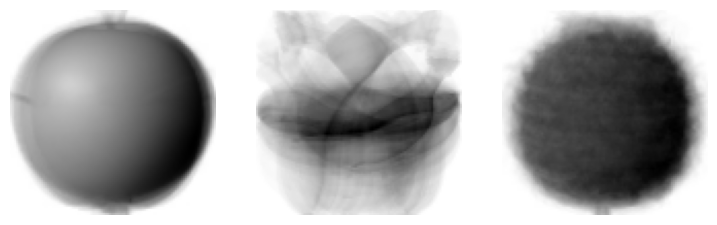

In [4]:
centers = (km.cluster_centers_ * 255).reshape(-1, 100, 100)
fig, axs = plt.subplots(1, 3, figsize=(9, 3))
for ax, center in zip(axs, centers):
    ax.imshow(center, cmap='gray_r')
    ax.axis('off')
plt.show()
